# Global Conflict & Economic Impact Analysis

## Phase 5 - Oil Price Analysis

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [ ]:
oil_df = pd.read_csv("clean_oil.csv")

oil_df.head()

,Year,Average_Oil_Price
0,1986,15.047689
1,1987,19.200512
2,1988,15.965409
3,1989,19.635486
4,1990,24.526576


In [ ]:
print("Shape :", oil_df.shape)

oil_df.info()

Shape : (41, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               41 non-null     int64  
 1   Average_Oil_Price  41 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 788.0 bytes


In [ ]:
oil_df.isnull().sum()

,0
Year,0
Average_Oil_Price,0


In [ ]:
oil_df.describe()

,Year,Average_Oil_Price
count,41.000000,41.000000
mean,2006.000000,49.030489
std,11.979149,28.957756
min,1986.000000,14.422072
25%,1996.000000,20.608254
50%,2006.000000,43.293651
75%,2016.000000,72.340595
max,2026.000000,99.671502


In [ ]:
oil_df.rename(
    columns={
        "DCOILWTICO":"Average_Oil_Price"
    },
    inplace=True
)

In [ ]:
highest = oil_df.loc[
    oil_df["Average_Oil_Price"].idxmax()
]

highest

,22
Year,2008.000000
Average_Oil_Price,99.671502


In [ ]:
lowest = oil_df.loc[
    oil_df["Average_Oil_Price"].idxmin()
]

lowest

,12
Year,1998.000000
Average_Oil_Price,14.422072


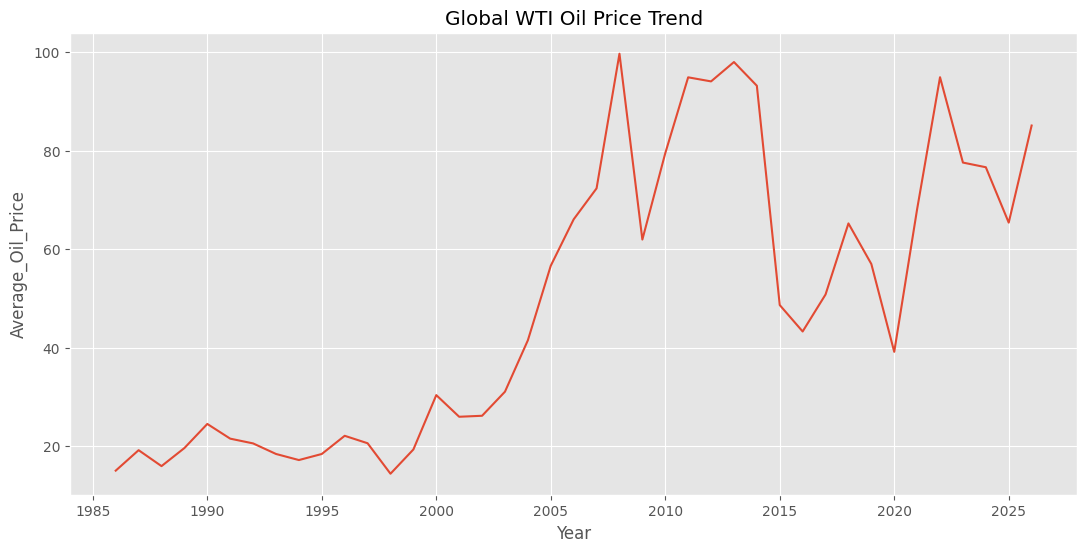

In [ ]:
plt.figure(figsize=(13,6))

sns.lineplot(
    data=oil_df,
    x="Year",
    y="Average_Oil_Price"
)

plt.title("Global WTI Oil Price Trend")

plt.show()

In [ ]:
fig = px.line(
    oil_df,
    x="Year",
    y="Average_Oil_Price",
    title="WTI Oil Price Trend"
)

fig.show()

In [ ]:
top10 = (
    oil_df
    .sort_values(
        "Average_Oil_Price",
        ascending=False
    )
    .head(10)
)

top10

,Year,Average_Oil_Price
22,2008,99.671502
27,2013,97.982540
36,2022,94.902869
25,2011,94.880873
26,2012,94.053333
28,2014,93.172222
40,2026,85.096814
24,2010,79.475714
37,2023,77.576532
38,2024,76.632240


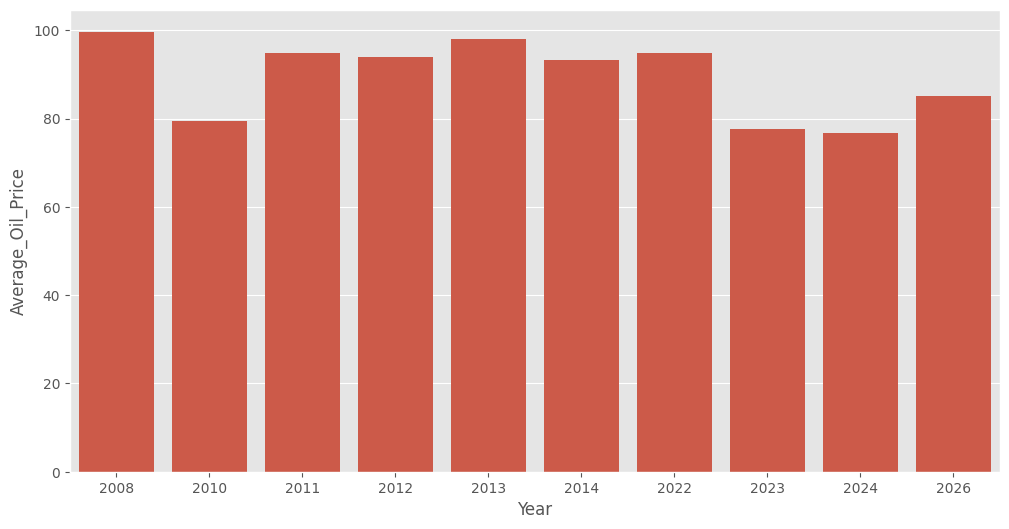

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Year",
    y="Average_Oil_Price"
)

plt.show()

In [ ]:
bottom10 = (
    oil_df
    .sort_values("Average_Oil_Price")
    .head(10)
)

bottom10

,Year,Average_Oil_Price
12,1998,14.422072
0,1986,15.047689
2,1988,15.965409
8,1994,17.196429
9,1995,18.428805
7,1993,18.432200
1,1987,19.200512
13,1999,19.344980
3,1989,19.635486
6,1992,20.575564


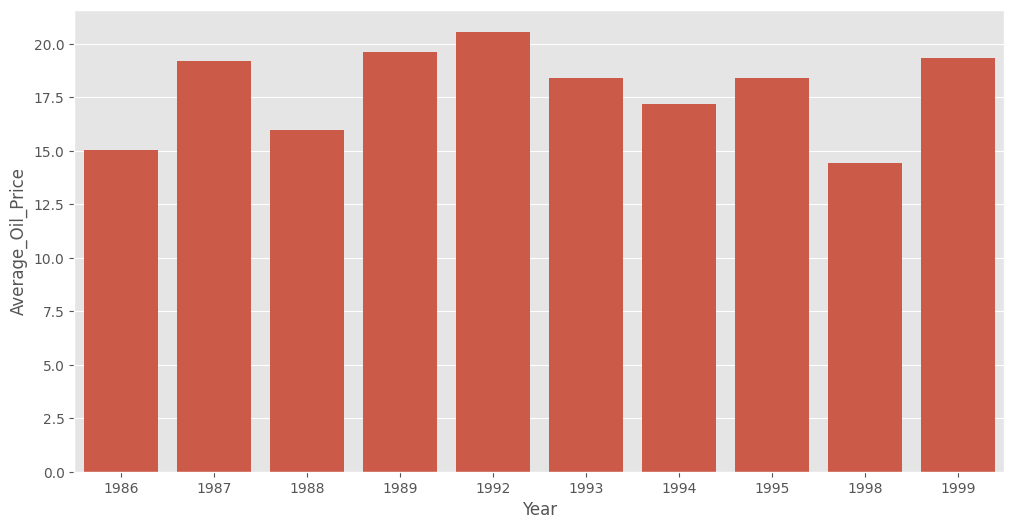

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom10,
    x="Year",
    y="Average_Oil_Price"
)

plt.show()

In [ ]:
oil_df = oil_df.sort_values("Year")

oil_df["Oil_Price_Change"] = (
    oil_df["Average_Oil_Price"]
    .diff()
)

oil_df.head()

,Year,Average_Oil_Price,Oil_Price_Change
0,1986,15.047689,NaN
1,1987,19.200512,4.152823
2,1988,15.965409,-3.235103
3,1989,19.635486,3.670078
4,1990,24.526576,4.891089


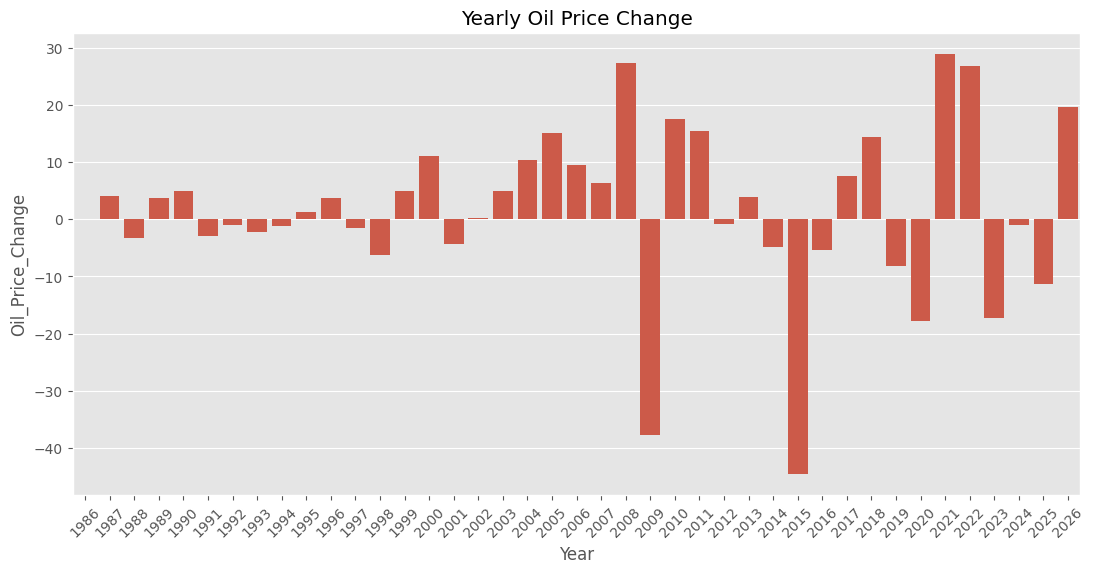

In [ ]:
plt.figure(figsize=(13,6))

sns.barplot(
    data=oil_df,
    x="Year",
    y="Oil_Price_Change"
)

plt.xticks(rotation=45)

plt.title("Yearly Oil Price Change")

plt.show()

In [ ]:
oil_df["Rolling_Average"] = (
    oil_df["Average_Oil_Price"]
    .rolling(3)
    .mean()
)

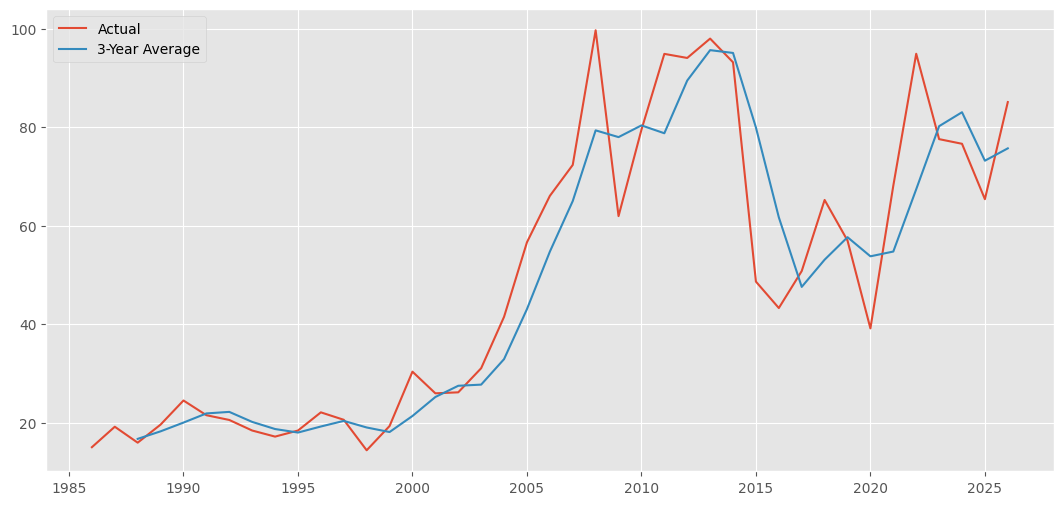

In [ ]:
plt.figure(figsize=(13,6))

plt.plot(
    oil_df["Year"],
    oil_df["Average_Oil_Price"],
    label="Actual"
)

plt.plot(
    oil_df["Year"],
    oil_df["Rolling_Average"],
    label="3-Year Average"
)

plt.legend()

plt.show()

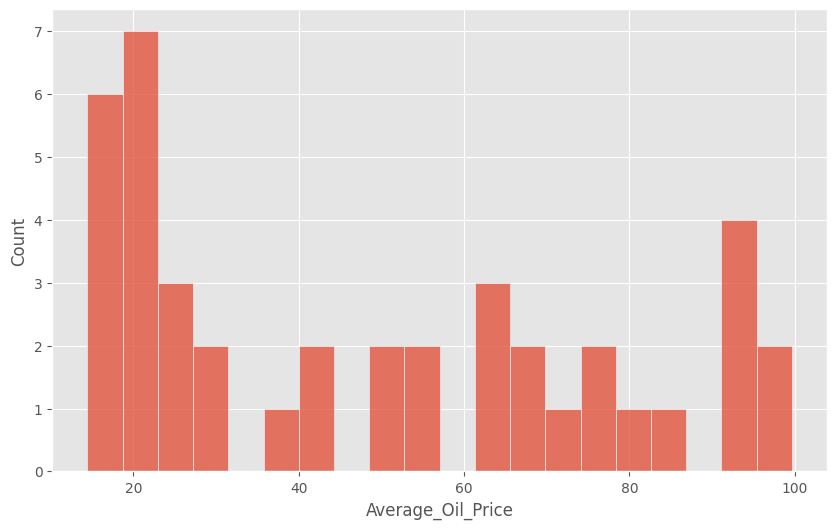

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    oil_df["Average_Oil_Price"],
    bins=20
)

plt.show()

In [ ]:
largest_jump = oil_df.loc[
    oil_df["Oil_Price_Change"].idxmax()
]

largest_jump

,35
Year,2021.000000
Average_Oil_Price,68.135100
Oil_Price_Change,28.974663
Rolling_Average,54.761285


In [ ]:
largest_drop = oil_df.loc[
    oil_df["Oil_Price_Change"].idxmin()
]

largest_drop

,29
Year,2015.000000
Average_Oil_Price,48.656706
Oil_Price_Change,-44.515516
Rolling_Average,79.937156


In [ ]:
oil_df["Volatility"] = (
    oil_df["Average_Oil_Price"]
    .pct_change() * 100
)

oil_df.head()

,Year,Average_Oil_Price,Oil_Price_Change,Rolling_Average,Volatility
0,1986,15.047689,NaN,NaN,NaN
1,1987,19.200512,4.152823,NaN,27.597743
2,1988,15.965409,-3.235103,16.737870,-16.849047
3,1989,19.635486,3.670078,18.267136,22.987685
4,1990,24.526576,4.891089,20.042490,24.909439


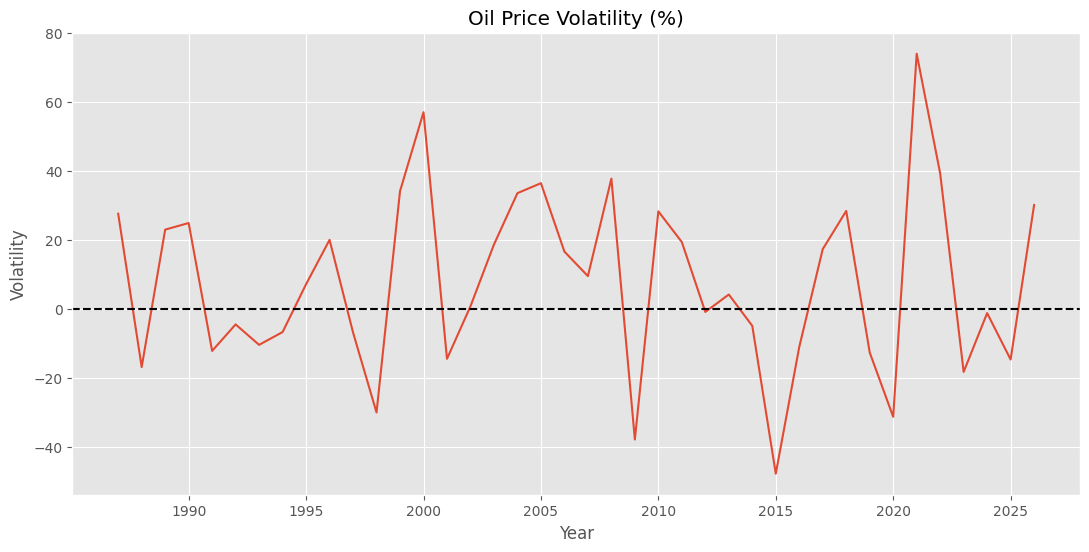

In [ ]:
plt.figure(figsize=(13,6))

sns.lineplot(
    data=oil_df,
    x="Year",
    y="Volatility"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Oil Price Volatility (%)")

plt.show()

In [ ]:
print(f"""

Highest Oil Price

Year :
{highest['Year']}

Price :
{highest['Average_Oil_Price']:.2f}

----------------------------

Lowest Oil Price

Year :
{lowest['Year']}

Price :
{lowest['Average_Oil_Price']:.2f}

Average Oil Price

{oil_df['Average_Oil_Price'].mean():.2f}

""")



Highest Oil Price

Year :
2008.0

Price :
99.67

----------------------------

Lowest Oil Price

Year :
1998.0

Price :
14.42

Average Oil Price

49.03




In [ ]:
oil_df.to_csv(
    "oil_analysis.csv",
    index=False
)

print("Phase 5 Completed Successfully")

Phase 5 Completed Successfully
